# Library

Import all required libraries for data processing, visualization, NLP, machine learning, and text vectorization.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf 
import re
import os
from tensorflow.keras import layers, models 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import wordcloud
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer




# Load Dataset

Load the Sentiment140 dataset (1.6M tweets) from a CSV file using Latin-1 encoding since it contains special characters.

In [5]:
# Load the dataset
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\DEPI\NLP_Projects\Twiter Task\archive\training.1600000.processed.noemoticon.csv", encoding='latin-1', header=None)    
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
# Set pandas to display the full content of each column without truncation
pd.set_option("display.max_colwidth", None)

In [7]:
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
print(df.head())
print(df.tail())

   target         ids                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user  \
0  _TheSpecialOne_   
1    scotthamilton   
2         mattycus   
3          ElleCTF   
4           Karoli   

                                                                                                                  text  
0  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D  
1      is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!  
2                            @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of b

In [8]:
df.drop(["flag", "user","date","ids"], axis=1, inplace=True)
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


In [10]:
df.describe()

,target
count,1.600000e+06
mean,2.000000e+00
std,2.000001e+00
min,0.000000e+00
25%,0.000000e+00
50%,2.000000e+00
75%,4.000000e+00
max,4.000000e+00


In [11]:
df.isnull().sum()

target    0
text      0
dtype: int64

# Preprocessing

Clean the tweet text by converting to lowercase, removing URLs, stripping punctuation, filtering out stop words (keeping "not"), and applying lemmatization to normalize words to their base form.

In [ ]:

# stop_words 
stop_words = set(stopwords.words('english'))
print(stop_words)
# remove all stop words except 'not'
stop_words.remove('not')
# lemmatizer 
lemmatizer = WordNetLemmatizer()
def preprocess_text():
    # Convert to lowercase
    df['text'] = df['text'].str.lower()
    
    # Remove URLs
    df['text'] = df['text'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x, flags=re.MULTILINE))
    
    # Remove punctuation
    df['text'] = df['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
    
    # Tokenization and stop word removal
    df['text'] = df['text'].apply(lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]))
    
    # Lemmatization
    df['text'] = df['text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(x)]))
    
   
preprocess_text()
print(df.head())

{'not', 'above', 'and', 'between', 'what', 'on', "we'd", 'a', 'in', 'haven', 'i', "isn't", 'against', 'during', 'out', 'hadn', 'we', 'are', 'ma', 'no', "they're", 'they', 'have', 'isn', 'them', 'themselves', 'again', 'our', 'yourselves', 'why', 'himself', 'from', 'once', 'of', 'only', 'for', 'shan', "wasn't", 'is', 'shouldn', 'being', 'my', 'm', 'wouldn', 'ain', 'o', "she'd", "it's", 'll', 'until', "didn't", "you'd", "it'd", 'needn', 'who', 'it', 'which', 'that', "mightn't", 'all', 'had', 'you', 't', 'up', 'by', 'your', 'there', 'under', 'so', 'been', 'mustn', "we'll", 'don', 'most', 'ourselves', 'here', 'through', "doesn't", 'more', "he'll", "couldn't", 'itself', 'were', "i'll", "that'll", 'yourself', 'because', "i'd", 'or', 'me', 're', 'where', 'should', 'won', 'he', "it'll", 'such', 'these', 'd', 'while', 'when', 'did', 'into', 'this', "hadn't", 'him', 'an', 'doing', 'was', 'as', "you'll", "they'd", 'myself', "she'll", "won't", 'theirs', 'am', "they'll", 'down', 'before', 'can', 'fu

In [ ]:
! pip install wordcloud

# Visualize Positive Words

Generate a word cloud from the preprocessed tweet text to visually explore the most frequent words in the dataset.

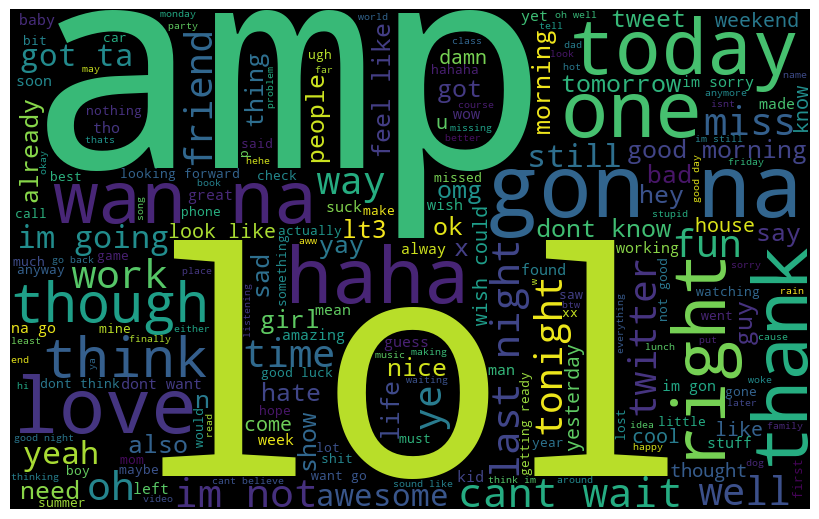

In [ ]:
words_list = df['text'].unique().tolist()
pos_words = " ".join(words_list)

pos_wordcloud =  WordCloud(
                  width=800, height = 500,            
                  stopwords=stop_words).generate(pos_words)

plt.figure(figsize=(8, 8), facecolor = None)
plt.imshow(pos_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


# Visualize Negative Words

Generate a second word cloud to further inspect word frequency distribution across the dataset.

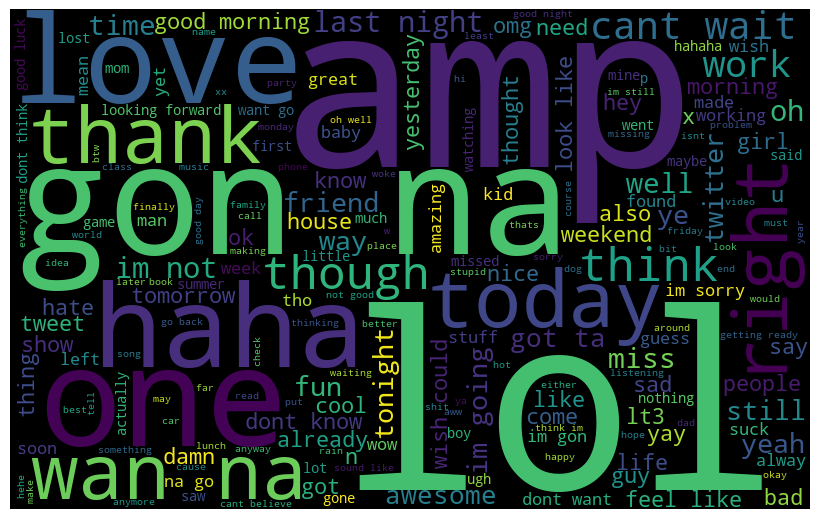

In [ ]:
words_list = df['text'].unique().tolist()
neg_words = " ".join(words_list)
neg_wordCloud = WordCloud(
    width=800, height=500, stopwords=stop_words).generate(neg_words)

plt.figure(figsize=(8,8), facecolor=None)
plt.imshow(neg_wordCloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# Train / Test Split

Split the dataset into training (70%) and testing (30%) sets using stratified sampling to preserve class balance.

In [ ]:
x = df['text'].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y , random_state=42)

print("Train data:",  X_train.shape, y_train.shape)
print("Test data:",  X_test.shape, y_test.shape)

Train data: (1120000,) (1120000,)
Test data: (480000,) (480000,)


# Vectorizing Text

Convert the cleaned tweet text into numerical feature vectors using two approaches:
- **Bag of Words (BoW):** counts word occurrences per document.
- **TF-IDF:** weights words by how informative they are across the corpus.

In [ ]:
# pag of word 
vect = CountVectorizer(min_df=10)

X_train_review_bow = vect.fit_transform(X_train)
X_test_review_bow = vect.transform(X_test)

print('X_train_review_bow shape: ', X_train_review_bow.shape)
print('X_test_review_bow shape: ', X_test_review_bow.shape)

X_train_review_bow shape:  (1120000, 31179)
X_test_review_bow shape:  (480000, 31179)


In [ ]:
# TF-IDF
vectorizer = TfidfVectorizer(min_df=10)

X_train_review_tfidf = vectorizer.fit_transform(X_train)
X_test_review_tfidf = vectorizer.transform(X_test)

print('X_train_review_tfidf shape: ', X_train_review_tfidf.shape)
print('X_test_review_tfidf shape: ', X_test_review_tfidf.shape)

X_train_review_tfidf shape:  (1120000, 31179)
X_test_review_tfidf shape:  (480000, 31179)


# Building ML Classifiers

Train and evaluate classification models to predict tweet sentiment (positive / negative).

## Logistic Regression — Bag of Words

Train a Logistic Regression model (L2 regularization) on the BoW feature matrix and evaluate its accuracy on the test set.

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(penalty='l2')
clf.fit(X_train_review_bow, y_train)

y_pred = clf.predict(X_test_review_bow) #prediction from model
print('Test Accuracy: ', accuracy_score(y_test, y_pred)) 

Test Accuracy:  0.7853208333333334


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


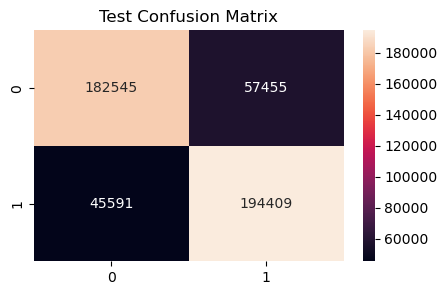

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Test Confusion Matrix')
plt.show()

## Logistic Regression — TF-IDF

Train the same Logistic Regression model on TF-IDF features to compare performance against the BoW representation.

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(penalty='l2')
clf.fit(X_train_review_tfidf, y_train)

y_pred = clf.predict(X_test_review_tfidf)
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

Test Accuracy:  0.78763125


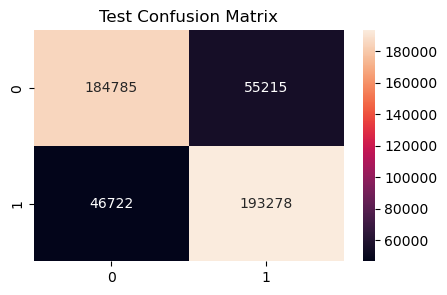

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Test Confusion Matrix')
plt.show()

## Naive Bayes — Bag of Words

Train a Multinomial Naive Bayes classifier on the BoW feature matrix and evaluate its test accuracy.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB()
clf.fit(X_train_review_bow, y_train)

y_pred = clf.predict(X_test_review_bow) #prediction from model
print('Test Accuracy: ', accuracy_score(y_test, y_pred)) 

Test Accuracy:  0.77355625


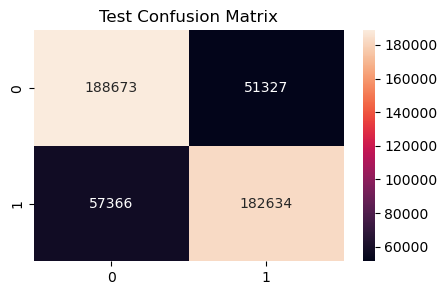

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Test Confusion Matrix')
plt.show()

## Naive Bayes — TF-IDF

Train a Multinomial Naive Bayes classifier on TF-IDF features and compare results with the BoW variant.

In [ ]:
clf = MultinomialNB(alpha=1)
clf.fit(X_train_review_tfidf, y_train)

y_pred = clf.predict(X_test_review_tfidf)
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

Test Accuracy:  0.7666729166666667


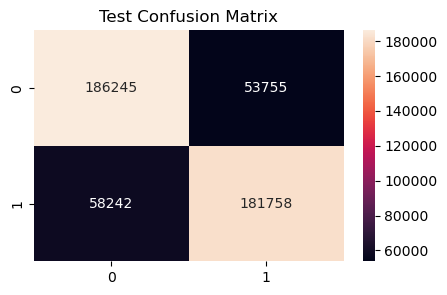

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Test Confusion Matrix')
plt.show()

## Model Comparison

Summarize and visualize the accuracy of all four model–vectorizer combinations in a table and a bar chart.

In [ ]:
! pip install prettytable

In [ ]:
from prettytable import PrettyTable

x = PrettyTable()

x.field_names = ['Vectorizer', 'Model', 'Accuracy']
x.add_row(['BOW', 'Naive Bayes', '77.3%'])
x.add_row(['TFIDF', 'Naive Bayes', '76.6%'])
x.add_row(['BOW', 'Logistic Regression', '78.5%'])
x.add_row(['TFIDF', 'Logistic Regression', '78.67%'])

print(x)

+------------+---------------------+----------+
| Vectorizer |        Model        | Accuracy |
+------------+---------------------+----------+
|    BOW     |     Naive Bayes     |  77.3%   |
|   TFIDF    |     Naive Bayes     |  76.6%   |
|    BOW     | Logistic Regression |  78.5%   |
|   TFIDF    | Logistic Regression |  78.67%  |
+------------+---------------------+----------+


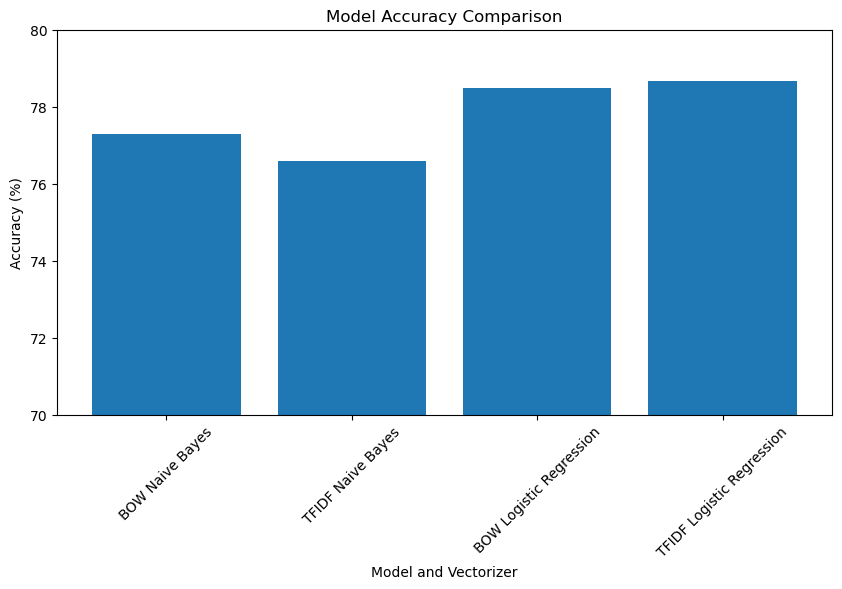

In [ ]:
import matplotlib.pyplot as plt

results = {
    'BOW Naive Bayes': 77.3,
    'TFIDF Naive Bayes': 76.6,
    'BOW Logistic Regression': 78.5,
    'TFIDF Logistic Regression': 78.67
}

plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values())


plt.xlabel('Model and Vectorizer')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')

plt.xticks(rotation=45)
plt.ylim(70, 80)

plt.show()